### Importing libraries:

In [13]:
import glob
import sys
import math
import json
import os
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Downloading dataset for the Contiguous United States:

We are downloading daily weather data averaged across the Contiguous United States (CONUS), sourced from the National Centers for Environmental Information (NCEI) website. This data covers three key meteorological factors: precipitation ($\text{prcp}$) in millimeters, and the maximum ($\text{tmax}$) and minimum ($\text{tmin}$) temperatures in Celsius. On the server, each file is uniquely identified using the format EEEE-YYYYMM-ste-scaled.csv, where EEEE specifies the weather factor (prcp, tmax, or tmin), YYYY ranges from 2014 through 2025, and MM represents the month, from 01 to 12. Crucially, the download process targets a distinct CSV file for every possible combination of a factor, a year, and a month within these specified ranges. 

In [ ]:
import requests
import os
import time

# File name components: EEEE-YYYYMM-ste-scaled.csv
ELEMENTS = ['prcp', 'tmax', 'tmin']
YEARS = [str(y) for y in range(2014, 2026)]  # Includes 2014 through 2025
MONTHS = [f'{m:02d}' for m in range(1, 13)]  # Includes '01' through '12'

# Base URL pattern where the YYYY is dynamic.
BASE_URL_PATTERN = "https://www.ncei.noaa.gov/data/nclimgrid-daily/access/averages/{YYYY}/"

# The directory where the downloaded files should be saved
DOWNLOAD_DIRECTORY = "../../data/raw/nclimgrid_daily_data"

# Counter for tracking progress
SUCCESS_COUNT = 0
FAIL_COUNT = 0


def download_csv_files():
    """
    Constructs URLs based on EEEE-YYYYMM pattern and dynamic YEAR URL,
    downloads the files, and saves them to a local directory.
    """
    global SUCCESS_COUNT, FAIL_COUNT
    total_files = len(ELEMENTS) * len(YEARS) * len(MONTHS)
    print(f"Starting download process for {total_files} file combinations...")

    # Create the download directory if it doesn't exist
    if not os.path.exists(DOWNLOAD_DIRECTORY):
        os.makedirs(DOWNLOAD_DIRECTORY)
        print(f"Created directory: {DOWNLOAD_DIRECTORY}")

    # Iterate through all combinations
    for year in YEARS:
        # Determine the year-specific base URL
        current_base_url = BASE_URL_PATTERN.format(YYYY=year)

        for element in ELEMENTS:
            for month in MONTHS:
                # Construct the full file name: EEEE-YYYYMM-ste-scaled.csv
                file_identifier = f"{year}{month}"
                local_filename = f"{element}-{file_identifier}-ste-scaled.csv"
                
                # Construct the full URL
                file_url = f"{current_base_url}{local_filename}"
                full_path = os.path.join(DOWNLOAD_DIRECTORY, local_filename)

                print(f"\n--- Attempting download: {local_filename} (Source: {year}/{month}) ---")

                try:
                    # 1. Make the HTTP request
                    # stream=True ensures we don't load the entire file into memory at once
                    response = requests.get(file_url, stream=True, timeout=15)

                    # 2. Check for successful response status (200 OK)
                    response.raise_for_status()

                    # 3. Write the content to a local file
                    with open(full_path, 'wb') as f:
                        for chunk in response.iter_content(chunk_size=8192):
                            if chunk:
                                f.write(chunk)

                    print(f"SUCCESS: Downloaded and saved to: {full_path}")
                    SUCCESS_COUNT += 1

                except requests.exceptions.HTTPError as errh:
                    FAIL_COUNT += 1
                    status_code = response.status_code if 'response' in locals() else 'N/A'
                    print(f"FAILURE (HTTP Error {status_code}): Could not find {local_filename}. Details: {errh}")
                except requests.exceptions.ConnectionError as errc:
                    FAIL_COUNT += 1
                    print(f"FAILURE (Connection Error): Check network connection. Details: {errc}")
                except requests.exceptions.Timeout as errt:
                    FAIL_COUNT += 1
                    print(f"FAILURE (Timeout Error): Server took too long to respond. Details: {errt}")
                except requests.exceptions.RequestException as err:
                    FAIL_COUNT += 1
                    print(f"FAILURE (General Error): An unexpected error occurred: {err}")

                # 4. Add a small delay to be polite to the server and avoid throttling
                time.sleep(0.5)

    print("\n==============================================")
    print("Download Process Complete.")
    print(f"Total Attempts: {total_files}")
    print(f"Successful Downloads: {SUCCESS_COUNT}")
    print(f"Failed Downloads: {FAIL_COUNT}")
    print(f"Files are saved in the directory: {DOWNLOAD_DIRECTORY}")
    print("==============================================")


if __name__ == "__main__":
    download_csv_files()

Starting download process for 432 file combinations...
Created directory: ./nclimgrid_daily_data

--- Attempting download: prcp-201401-ste-scaled.csv (Source: 2014/01) ---
SUCCESS: Downloaded and saved to: ./nclimgrid_daily_data/prcp-201401-ste-scaled.csv

--- Attempting download: prcp-201402-ste-scaled.csv (Source: 2014/02) ---
SUCCESS: Downloaded and saved to: ./nclimgrid_daily_data/prcp-201402-ste-scaled.csv

--- Attempting download: prcp-201403-ste-scaled.csv (Source: 2014/03) ---
SUCCESS: Downloaded and saved to: ./nclimgrid_daily_data/prcp-201403-ste-scaled.csv

--- Attempting download: prcp-201404-ste-scaled.csv (Source: 2014/04) ---
SUCCESS: Downloaded and saved to: ./nclimgrid_daily_data/prcp-201404-ste-scaled.csv

--- Attempting download: prcp-201405-ste-scaled.csv (Source: 2014/05) ---
SUCCESS: Downloaded and saved to: ./nclimgrid_daily_data/prcp-201405-ste-scaled.csv

--- Attempting download: prcp-201406-ste-scaled.csv (Source: 2014/06) ---
SUCCESS: Downloaded and saved to:

### Hawaii Data Sourcing and County-Level Aggregation

Since the primary Contiguous United States (CONUS) climate dataset excludes Hawaii and Alaska (and the related bee colony loss data similarly omits Alaska), we must manually source the weather data for Hawaii. To do this, we are moving away from the area-averaged NCEI files and utilizing NOAA's station-based data interface, which covers all U.S. territories. It is important to note that this method will not provide a single daily average value for the entire state; instead, it delivers daily average precipitation, maximum temperature, and minimum temperature values for individual counties within Hawaii. We will subsequently use these county-level figures to calculate the required state-level average for the period spanning 2015 through 2025.

In [ ]:
#we will create list of dataframes, where each list corresponds to a year of data
hawaii_raw = [] 

# Iterate through the range of years
for year in range(2014, 2026):
    
    file_path = f'../../data/raw/HI_{year}.csv'
    
    df = pd.read_csv(file_path)
    hawaii_raw.append(df)
    print(f"Successfully read HI_{year}")
    print(hawaii_raw[year-2014].head())

Successfully read HI_2014
       STATION                     NAME        DATE  PRCP  TMAX  TMIN
0  USW00022519  KANEOHE BAY MCAS, HI US  2014-01-01   NaN  82.0  72.0
1  USW00022519  KANEOHE BAY MCAS, HI US  2014-01-02   NaN  82.0  73.0
2  USW00022519  KANEOHE BAY MCAS, HI US  2014-01-03   NaN   NaN   NaN
3  USW00022519  KANEOHE BAY MCAS, HI US  2014-01-04   NaN  82.0  72.0
4  USW00022519  KANEOHE BAY MCAS, HI US  2014-01-05  0.41  81.0  72.0
Successfully read HI_2015
       STATION                     NAME        DATE  PRCP  TMAX  TMIN
0  USW00022519  KANEOHE BAY MCAS, HI US  2015-01-01  0.00  76.0  60.0
1  USW00022519  KANEOHE BAY MCAS, HI US  2015-01-02  0.73  78.0  63.0
2  USW00022519  KANEOHE BAY MCAS, HI US  2015-01-03  0.00  75.0  63.0
3  USW00022519  KANEOHE BAY MCAS, HI US  2015-01-04  0.00  76.0  62.0
4  USW00022519  KANEOHE BAY MCAS, HI US  2015-01-05  0.00  77.0  60.0
Successfully read HI_2016
       STATION                     NAME        DATE  PRCP  TMAX  TMIN
0  USW000225

Note that the data for Hawaii is not in S.I. units, so we need to convert the precipitation from inches to mm and temperature from degree Faranhite to degree Celcius. 

In [4]:
def clean_and_aggregate_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    1. Converts PRCP (inches -> mm) and TMAX/TMIN (Fahrenheit -> Celsius).
    2. Calculates the daily average for these metrics across all stations
       within a single DataFrame, and removes the 'STATION' and 'NAME' columns.

    Args:
        df (pd.DataFrame): A DataFrame with columns 'STATION', 'NAME', 'DATE',
                           'PRCP' (inches), 'TMAX' (°F), and 'TMIN' (°F).

    Returns:
        pd.DataFrame: A new DataFrame grouped by 'DATE' with aggregated mean
                      values in millimeters (mm) and Celsius (°C).
    """
    
    # --- 1. Unit Conversion ---
    
    # Conversion of Precipitation (PRCP): Inches to Millimeters (1 inch = 25.4 mm)
    # .copy() is used here to ensure we are modifying a copy and avoid SettingWithCopyWarning
    df_converted = df.copy() 
    df_converted['PRCP'] = df_converted['PRCP'] * 25.4
    
    # Conversion of Temperature (TMAX, TMIN): Fahrenheit to Celsius (C = (F - 32) * 5/9)
    # The lambda function handles potential NaN values correctly during the operation.
    df_converted['TMAX'] = (df_converted['TMAX'] - 32) * (5/9)
    df_converted['TMIN'] = (df_converted['TMIN'] - 32) * (5/9)
    
    # --- 2. Aggregation ---
    
    # Group by 'DATE' and calculate the mean for the converted columns.
    aggregated_df = df_converted.groupby('DATE')[['PRCP', 'TMAX', 'TMIN']].mean().reset_index()

    return aggregated_df

hawaii_processed_1 = []
for i, df in enumerate(hawaii_raw):
    print(f"Processing DataFrame {i+1}...")
    try:
        # Apply the aggregation function
        aggregated_df = clean_and_aggregate_dataframe(df)
        hawaii_processed_1.append(aggregated_df)
        print(f"DataFrame {i+1} processed successfully.")
    except Exception as e:
        print(f"Error processing DataFrame {i+1}: {e}")
        # Append an empty DataFrame or handle the error as needed
        hawaii_processed_1.append(pd.DataFrame())
    print(hawaii_processed_1[i].head())

Processing DataFrame 1...
DataFrame 1 processed successfully.
         DATE       PRCP       TMAX       TMIN
0  2014-01-01   5.864478  24.960317  15.763889
1  2014-01-02   6.754678  25.076923  16.384615
2  2014-01-03  14.464082  23.623549  16.393035
3  2014-01-04   3.770243  22.827381  15.605159
4  2014-01-05   4.047537  22.509921  14.503968
Processing DataFrame 2...
DataFrame 2 processed successfully.
         DATE       PRCP       TMAX       TMIN
0  2015-01-01   0.211015  22.589286  13.939394
1  2015-01-02   4.104201  22.954145  15.079365
2  2015-01-03  21.895564  22.368973  13.750000
3  2015-01-04   2.116030  22.172619  12.949495
4  2015-01-05   3.213274  23.128205  12.888889
Processing DataFrame 3...
DataFrame 3 processed successfully.
         DATE      PRCP       TMAX       TMIN
0  2016-01-01  2.457398  24.743590  15.149573
1  2016-01-02  2.540000  24.360587  15.283019
2  2016-01-03  0.051210  24.106754  15.128205
3  2016-01-04  1.117187  23.828283  14.828283
4  2016-01-05  1.333

In [5]:
def reshape_yearly_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transforms a daily average weather DataFrame (one year) into a matrix format,
    where rows represent (Year, Feature, Month) and columns represent Day (1 to 31).

    Args:
        df (pd.DataFrame): Input DataFrame with columns: 
                           'DATE', 'PRCP', 'TMAX', 'TMIN'.

    Returns:
        pd.DataFrame: Reshaped DataFrame with columns 'Year', 'Feature', 'Month', 
                      and 'Day_1' through 'Day_31'.
    """
    
    # --- 1. Extract Year, Month, and Day components ---
    df['DATE'] = pd.to_datetime(df['DATE'])
    df['Year'] = df['DATE'].dt.year  # Extract the year
    df['Month'] = df['DATE'].dt.month
    df['Day'] = df['DATE'].dt.day
    
    # Define the columns that contain the actual weather values
    value_vars = ['PRCP', 'TMAX', 'TMIN']

    # --- 2. Melt (Unpivot) the features ---
    # Convert 'PRCP', 'TMAX', and 'TMIN' from separate columns into rows.
    # We now include 'Year' in the identifier columns.
    df_melted = df.melt(
        id_vars=['Year', 'Month', 'Day'], # Keep these as identifier columns
        value_vars=value_vars,
        var_name='Feature',
        value_name='Value'
    )
    
    # --- 3. Pivot the 'Day' into columns ---
    # Set the index to be 'Year', 'Feature', and 'Month', and let 'Day' become the columns.
    df_pivoted = df_melted.pivot_table(
        index=['Year', 'Feature', 'Month'],
        columns='Day',
        values='Value',
        # Use dropna=False to explicitly create columns for all days (1 to 31).
        dropna=False 
    ).reset_index()

    # --- NEW ADDITIONS ---
    # Add the requested constant columns
    df_pivoted['ran'] = 'ste'
    # Ensure state_id is int64 as requested (it should be, but we ensure it)
    df_pivoted['state_id'] = 49 
    df_pivoted['state_name'] = 'Hawaii'

    # --- 4. Final Cleanup and Formatting ---
    
    # Remove the name of the column index (which is 'Day')
    df_pivoted.columns.name = None 
    
    # Create the required Day_1, Day_2, ... column names
    day_cols_map = {i: f'Day_{i:02}' for i in range(1, 32)}
    df_pivoted = df_pivoted.rename(columns=day_cols_map)
    
    # Select and order the final columns
    final_cols_order = ['ran', 'state_id', 'state_name','Year', 'Month', 'Feature'] + [f'Day_{i:02}' for i in range(1, 32)]
    
    return df_pivoted[final_cols_order]

hawaii_reshaped = []
for i, df in enumerate(hawaii_processed_1):
    print(f"Reshaping DataFrame for year {i+1}...")
    try:
        reshaped_df = reshape_yearly_data(df)
        hawaii_reshaped.append(reshaped_df)
        print(f"Reshaping for year {i+1} complete.")
    except Exception as e:
        print(f"Error reshaping DataFrame {i+1}: {e}")
        hawaii_reshaped.append(pd.DataFrame())
    print(hawaii_reshaped[i].tail())    

Reshaping DataFrame for year 1...
Reshaping for year 1 complete.
    ran  state_id state_name  Year  Month Feature     Day_01     Day_02  \
31  ste        49     Hawaii  2014      8    TMIN  19.920635  21.265432   
32  ste        49     Hawaii  2014      9    TMIN  19.623352  19.330065   
33  ste        49     Hawaii  2014     10    TMIN  19.285714  19.029982   
34  ste        49     Hawaii  2014     11    TMIN  20.545073  20.393939   
35  ste        49     Hawaii  2014     12    TMIN  16.867031  16.028192   

       Day_03     Day_04  ...     Day_22     Day_23     Day_24     Day_25  \
31  20.902778  20.555556  ...  20.056361  19.781746  19.682540  19.747475   
32  19.828431  18.863636  ...  20.309654  20.286458  20.072860  20.451389   
33  19.381720  19.979424  ...  19.244792  19.611993  19.366319  19.411765   
34  20.367647  19.344942  ...  18.542977  16.976496  17.361111  16.854839   
35  16.252073  16.848958  ...  16.348039  16.301824  15.740741  15.050505   

       Day_26     Day

### Advanced precipitation features: 

Using the daily gridded precipitation data from 2014 through 2025, we will calculate four advanced quarterly features to enrich our analysis. This will result in a new DataFrame, prcp_final_df, which includes: 1) The average precipitation (in mm) for the quarter (e.g. Quarter 1 are Months 1-3); 2) The average precipitation (in mm) for each month in the quarter; 3)The maximum precipitation (in mm) for each month in the quarter; and 4) The count of consecutive wet periods, defined as the number of instances where rainfall exceeded 5mm for five or more consecutive days. 

In [ ]:
# Template for the file path structure
FILE_NAME_TEMPLATE = "nclimgrid_daily_data/prcp-{year}{month}-ste-scaled.csv"

# We will be combining precipitation data for each year as a new dataframe and store it in this list below
prcp_yearly_df = {}

# --- DEFINED COLUMN NAMES FOR THE RAW YEARLY DATA (36 COLUMNS) ---
# Assuming the raw monthly files contain 'ran', 'state_id', 'state_name', 
# followed by 31 daily data columns.
RAW_DATA_COLUMN_NAMES = (['ran', 'state_id', 'state_name','Year', 'Month', 'Feature'] + 
                         [f'Day_{i:02}' for i in range(1, 32)] 
)

# Loop through the required years
for year in range(2014, 2026):
    monthly_dfs = []
    year_str = str(year)
    
    # Loop through the months (1 to 12)
    for month in range(1, 13):
        # Format month as a two-digit string (e.g., 1 -> '01', 12 -> '12')
        month_str = str(month).zfill(2)
        
        # Construct the file name using the template
        relative_filepath = FILE_NAME_TEMPLATE.format(year=year_str, month=month_str)
        
        # Construct the full, absolute path
        full_path = os.path.join( '../../data/raw/nclimgrid_daily_data', relative_filepath)
        
        try:
            # Read the CSV file
            df = pd.read_csv(full_path,header=None)
            monthly_dfs.append(df)
            #print(f"  Successfully read {year_str}-{month_str}")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {year_str}-{month_str}: File not found.")
        except Exception as e:
            # Catch other potential errors (e.g., corrupted file)
            print(f"  ❌ Error reading {year_str}-{month_str}: {e}")
            
    # --- End of Month Loop ---
    
# Check if any monthly files were successfully read for the current year
    if monthly_dfs:
        # Concatenate all monthly dataframes into a single yearly dataframe
        yearly_df = pd.concat(monthly_dfs, ignore_index=True)
        
        # --- ADDED: Assign the explicit column names ---
        if len(yearly_df.columns) == len(RAW_DATA_COLUMN_NAMES):
            yearly_df.columns = RAW_DATA_COLUMN_NAMES
            print(f"   ✅ Columns successfully renamed for Year {year}.")
        else:
            print(f"   ❌ WARNING: Column count mismatch for Year {year}.")
            print(f"   Expected {len(RAW_DATA_COLUMN_NAMES)} columns but found {len(yearly_df.columns)}. Column renaming skipped.")
            
        prcp_yearly_df[year] = yearly_df
        print(f"\n✅ Finished combining data for Year {year}. Total rows: {len(yearly_df)}.")
        print(prcp_yearly_df[year].head())
    else:
        print(f"\nSkipping Year {year}: No data files found.")

   ✅ Columns successfully renamed for Year 2014.

✅ Finished combining data for Year 2014. Total rows: 576.
   ran  state_id  state_name  Year  Month Feature  Day_01  Day_02  Day_03  \
0  ste         1     Alabama  2014      1    PRCP    0.41    6.77    1.30   
1  ste         2     Arizona  2014      1    PRCP    0.00    0.00    0.00   
2  ste         3    Arkansas  2014      1    PRCP    0.00    0.21    0.00   
3  ste         4  California  2014      1    PRCP    0.00    0.00    0.00   
4  ste         5    Colorado  2014      1    PRCP    0.49    0.93    0.04   

   Day_04  ...  Day_22  Day_23  Day_24  Day_25  Day_26  Day_27  Day_28  \
0    0.00  ...     0.0    0.00    0.00    0.00     0.0    0.10    1.48   
1    0.00  ...     0.0    0.00    0.00    0.01     0.0    0.00    0.00   
2    0.00  ...     0.0    0.00    0.00    0.00     0.0    0.00    0.00   
3    0.00  ...     0.0    0.00    0.00    0.00     0.0    0.00    0.14   
4    0.58  ...     0.0    0.93    0.09    0.00     0.0    0

In [15]:
# Iterate through the list of reshaped dataframes
for i in range(len(hawaii_reshaped)):
    # Calculate the current year based on the list index (0 + 2014 = 2014)
    current_year = i + 2014
    
    # 1. Get the source (reshaped) DataFrame
    source_df = hawaii_reshaped[i]
    
    # 2. Filter the source DataFrame for PRCP rows and the current year
    # We look for the 'PRCP' value in the 'Feature' column, which matches the 
    # structure created in the weather_matrix_transformer file.
    
    prcp_rows_to_add = source_df[
        (source_df['Feature'] == 'PRCP') & 
        (source_df['Year'] == current_year)
    ].copy()
    #print(prcp_rows_to_add.head())
        
    # 3. Get the target DataFrame
    target_df = prcp_yearly_df[current_year]

    # 4. Concatenate (append) the filtered rows to the target DataFrame
    # pandas concat is used for appending rows. It handles the extra columns
    # in target_df by aligning on column names and filling NaNs where necessary.
    updated_df = pd.concat([target_df, prcp_rows_to_add], ignore_index=True)
    
    # --- ADDED STEP: Sort the DataFrame by 'Month' ---
    # This sorts all rows (original and appended) based on the month number
    updated_df = updated_df.sort_values(by='Month', ignore_index=True)

    # 5. Update the dictionary with the new DataFrame
    prcp_yearly_df[current_year] = updated_df
    print(f"✅ Appended {len(prcp_rows_to_add)} PRCP rows to data for year {current_year}. Total rows now: {len(updated_df)}.")
    print(prcp_yearly_df[current_year].head())


✅ Appended 12 PRCP rows to data for year 2014. Total rows now: 588.
   ran  state_id      state_name  Year  Month Feature  Day_01  Day_02  Day_03  \
0  ste         1         Alabama  2014      1    PRCP    0.41    6.77    1.30   
1  ste        28      New Jersey  2014      1    PRCP    0.00    0.01   15.24   
2  ste        29      New Mexico  2014      1    PRCP    0.00    0.00    0.00   
3  ste        30        New York  2014      1    PRCP    1.57    2.53    8.91   
4  ste        31  North Carolina  2014      1    PRCP    0.00    1.72    8.68   

   Day_04  ...  Day_22  Day_23  Day_24  Day_25  Day_26  Day_27  Day_28  \
0    0.00  ...    0.00    0.00    0.00    0.00    0.00    0.10    1.48   
1    0.00  ...   10.04    0.00    0.00    0.00    2.21    0.00    0.00   
2    0.00  ...    0.00    0.01    0.06    0.00    0.00    0.00    0.00   
3    0.05  ...    0.41    0.04    0.19    0.08    2.06    0.75    0.89   
4    0.01  ...    1.53    0.00    0.00    0.00    0.07    0.01    0.01   



In [16]:
def aggregate_to_quarters(prcp_yearly_df):
    """
    Transforms a dictionary of yearly DataFrames into a single quarterly DataFrame.

    Input DataFrames (prcp_yearly_df[year]) are expected to have rows for
    each Month (1-12) and columns 'Day_1' through 'Day_31'.

    Output DataFrame (prcp_quaterly_df) will have one row per quarter,
    with 93 new columns (M1_Day_1...M3_Day_31) representing the
    three months in that quarter.
    """
    
    all_quarterly_dfs = []
    
    # Define the day columns to be pivoted (using 31 as per input structure)
    day_cols = [f'Day_{i:02}' for i in range(1, 32)]
    
    # Define the base ID columns that will be kept
    base_id_cols = ['ran', 'state_id', 'state_name', 'Year', 'Feature']
    
    # Define quarter mapping
    quarter_bins = [0, 3, 6, 9, 12]
    quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']

    # Iterate through each year's DataFrame in the input dictionary
    for year, year_df in prcp_yearly_df.items():
        
        #print(f"\nProcessing Year {year}...")
        
        # Ensure the required columns exist
        if 'Month' not in year_df.columns:
            print(f"  ⚠️ Skipping Year {year}: 'Month' column not found.")
            continue
            
        # --- 1. Prepare for Pivot ---
        temp_df = year_df.copy()
        
        # a. Assign a 'Quarter' (Q1, Q2, Q3, Q4) to each month
        temp_df['Quarter'] = pd.cut(
            temp_df['Month'], 
            bins=quarter_bins, 
            labels=quarter_labels, 
            right=True
        )
        
        # b. Assign a month-in-quarter (M1, M2, M3)
        # (Month 1, 4, 7, 10) -> M1
        # (Month 2, 5, 8, 11) -> M2
        # (Month 3, 6, 9, 12) -> M3
        temp_df['Month_in_Quarter'] = 'M' + ((temp_df['Month'] - 1) % 3 + 1).astype(str)
        
        # --- 2. Perform the Pivot ---
        # We group by the base IDs + the new Quarter
        pivot_index = base_id_cols + ['Quarter']
        
        try:
            # Pivot the 3 monthly rows into 93 columns
            pivoted_df = temp_df.pivot_table(
                index=pivot_index,
                columns='Month_in_Quarter', # Creates M1, M2, M3
                values=day_cols,            # Creates Day_1...Day_31
                aggfunc='first' # Assumes one value per (Year, Month, Feature...)
            )
            
            # --- 3. Restructure Columns ---
            # The pivot creates ('Day_1', 'M1'), ('Day_1', 'M2')...
            # We want ('M1', 'Day_1'), ('M1', 'Day_2')...
            
            # a. Swap column levels: ('M1', 'Day_1')
            pivoted_df.columns = pivoted_df.columns.swaplevel(0, 1)
            
            # b. Sort columns by Month_in_Quarter first, then by Day
            pivoted_df.sort_index(axis=1, level=[0, 1], inplace=True)
            
            # c. Flatten the MultiIndex columns to 'M1_Day_1' format
            pivoted_df.columns = [
                f'{level_0}_{level_1}' 
                for level_0, level_1 in pivoted_df.columns
            ]
            
            # d. Bring the index (ID columns) back as columns
            pivoted_df.reset_index(inplace=True)
            
            all_quarterly_dfs.append(pivoted_df)
            #print(f"  ✅ Successfully aggregated Year {year} into quarters.")

        except Exception as e:
            print(f"  ❌ Error pivoting data for Year {year}: {e}")
            print("     This can happen if data is missing for some months in a quarter.")
            continue
            
    # --- 4. Combine all processed years ---
    if not all_quarterly_dfs:
        print("\nNo data was successfully processed.")
        return pd.DataFrame()

    prcp_quaterly_df = pd.concat(all_quarterly_dfs, ignore_index=True)
    print(f"\n🎉 Quarterly aggregation complete. Total rows in new DataFrame: {len(prcp_quaterly_df)}")
    
    return prcp_quaterly_df

In [17]:
prcp_quaterly_df = aggregate_to_quarters(prcp_yearly_df)
#print(prcp_quaterly_df.head())
#print(prcp_quaterly_df.tail())
prcp_quaterly_df.info()


🎉 Quarterly aggregation complete. Total rows in new DataFrame: 2304
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 99 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ran         2304 non-null   object  
 1   state_id    2304 non-null   int64   
 2   state_name  2304 non-null   object  
 3   Year        2304 non-null   int64   
 4   Feature     2304 non-null   object  
 5   Quarter     2304 non-null   category
 6   M1_Day_01   2304 non-null   float64 
 7   M1_Day_02   2304 non-null   float64 
 8   M1_Day_03   2304 non-null   float64 
 9   M1_Day_04   2304 non-null   float64 
 10  M1_Day_05   2304 non-null   float64 
 11  M1_Day_06   2304 non-null   float64 
 12  M1_Day_07   2304 non-null   float64 
 13  M1_Day_08   2304 non-null   float64 
 14  M1_Day_09   2304 non-null   float64 
 15  M1_Day_10   2304 non-null   float64 
 16  M1_Day_11   2304 non-null   float64 
 17  M1_Day_12   2304 non-

/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/1000902842.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/1000902842.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/1000902842.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984

In [18]:
# --- Helper Function for Consecutive Rain Days ---

# Define the columns for M1,M2 and M3 outside the function for efficiency
M1_COLS = [f'M1_Day_{i:02d}' for i in range(1, 32)]
M2_COLS = [f'M2_Day_{i:02d}' for i in range(1, 32)]
M3_COLS = [f'M3_Day_{i:02d}' for i in range(1, 32)]

# Define all day columns for the new quarterly average
ALL_DAY_COLS = M1_COLS + M2_COLS + M3_COLS # Total 93 columns


def count_consecutive_events(row):
    """
    Counts the number of "events" where 4 or more consecutive days
    had a value > 5. An event is a distinct group.
    (e.g., 7 consecutive days is 1 event, not 4).
    
    This check is only performed on the 93 columns from M1 and M2.
    """
    # Select the 93 days of data for this row
    days_data = row[ALL_DAY_COLS]
    
    # Create a boolean series: True if > 5, False if <= 5 or NaN
    is_rain = days_data > 5
    
    event_count = 0
    current_streak = 0
    in_event = False # Flag to ensure we only count one event per streak
    
    for day_is_rain in is_rain:
        if day_is_rain:
            current_streak += 1
        else:
            # The streak is broken (it was False or NaN)
            current_streak = 0
            in_event = False
        
        # Check if we've just hit a 4-day streak
        if current_streak >= 4 and not in_event:
            event_count += 1
            in_event = True # Mark that we are in a 4+ day event
            
    return event_count

# --- Main Transformation Function ---

def summarize_quarterly_data(prcp_quaterly_df):
    """
    Calculates monthly averages and consecutive rain days from the
    quarterly data.
    """
    
    print("Starting quarterly summary...")
    
    # Work on a copy to avoid modifying the original
    df = prcp_quaterly_df.copy()
    
    # --- 1. Define Column Groups ---
    # Using the globally defined lists
    m1_day_cols = M1_COLS
    m2_day_cols = M2_COLS
    m3_day_cols = M3_COLS
    all_day_cols = ALL_DAY_COLS # Use the new 93-column list
    
    # --- 2. Calculate Monthly Averages ---
    # .mean(axis=1) calculates the average horizontally (row-wise)
    # We use .where(lambda x: x >= 0) to replace negative values with NaN
    # before calculating the mean. This effectively ignores negative values.
    # skipna=True is the default, which also handles your NaN requirement
    #print("Calculating monthly averages (ignoring negative values)...")
    df['M1_avg_prcp'] = df[m1_day_cols].where(lambda x: x >= 0).mean(axis=1)
    df['M2_avg_prcp'] = df[m2_day_cols].where(lambda x: x >= 0).mean(axis=1)
    df['M3_avg_prcp'] = df[m3_day_cols].where(lambda x: x >= 0).mean(axis=1)

    # --- 2b. Calculate Quarterly Average ---
    #print("Calculating full quarterly average (ignoring negative values)...")
    df['Q_prcp_avg'] = df[all_day_cols].where(lambda x: x >= 0).mean(axis=1)

    # --- 2c. Calculate Monthly Maximums ---
    # .max(axis=1) finds the max value horizontally. 
    # By default, it skips NaN values.
    print("Calculating monthly maximums...")
    df['M1_max_prcp'] = df[m1_day_cols].max(axis=1)
    df['M2_max_prcp'] = df[m2_day_cols].max(axis=1)
    df['M3_max_prcp'] = df[m3_day_cols].max(axis=1)
    
    # --- 3. Calculate Consecutive Rain Days ---
    # This is the most complex step and requires .apply()
    df['Consecutive_Rain_Days'] = df.apply(count_consecutive_events, axis=1)
    
    # --- 4. Create Final DataFrame ---
    # Define the final columns
    final_cols = [
        'state_id', 
        'state_name', 
        'Year', 
        'Feature', 
        'Quarter',
        'M1_avg_prcp',
        'M2_avg_prcp',
        'M3_avg_prcp',
        'M1_max_prcp', 
        'M2_max_prcp', 
        'M3_max_prcp',
        'Q_prcp_avg',
        'Consecutive_Rain_Days'
    ]
    
    # Select only these columns
    prcp_final_df = df[final_cols]
    
    print("Quarterly summary complete.")
    return prcp_final_df

In [25]:
prcp_final_df = summarize_quarterly_data(prcp_quaterly_df)
#prcp_final_df.info()
#print(prcp_final_df.head(10))
print(prcp_final_df.tail(10))

Starting quarterly summary...
Calculating monthly maximums...
Quarterly summary complete.
      state_id state_name  Year Feature Quarter  M1_avg_prcp  M2_avg_prcp  \
2294        47  Wisconsin  2025    PRCP      Q1     0.187742     0.740714   
2295        47  Wisconsin  2025    PRCP      Q2     2.708333     2.034839   
2296        47  Wisconsin  2025    PRCP      Q3     3.744516     3.037742   
2297        48    Wyoming  2025    PRCP      Q1     0.684194     1.210357   
2298        48    Wyoming  2025    PRCP      Q2     1.327333     1.638710   
2299        48    Wyoming  2025    PRCP      Q3     1.018387     0.748387   
2300        49     Hawaii  2025    PRCP      Q1     6.158171     1.944979   
2301        49     Hawaii  2025    PRCP      Q2     3.924237     2.707402   
2302        49     Hawaii  2025    PRCP      Q3     2.087500     1.045449   
2303        49     Hawaii  2025    PRCP      Q4     2.327328          NaN   

      M3_avg_prcp  M1_max_prcp  M2_max_prcp  M3_max_prcp  Q_pr

Calculating NaN counts by year...

Data to plot:
  Quarter  NaN_Count
0      Q1          0
1      Q2          0
2      Q3         48
3      Q4          1

Displaying plot...


/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/2613556392.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nan_counts_by_year = prcp_final_df.groupby('Quarter')['M3_max_prcp'].apply(lambda x: x.isna().sum())


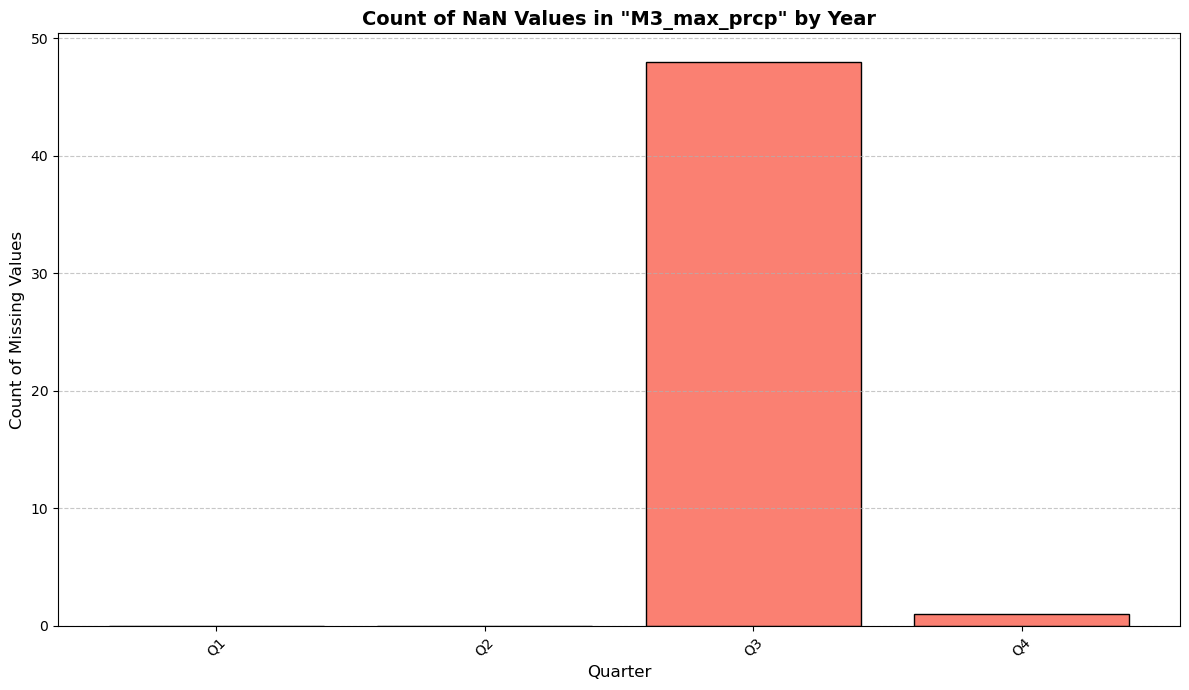

In [24]:
# # 1. Group by 'Year' and count the 'NaN' values in 'M3_max_prcp'
# We use .apply() to run the isna().sum() check on each group.
print("Calculating NaN counts by year...")
nan_counts_by_year = prcp_final_df.groupby('Quarter')['M3_max_prcp'].apply(lambda x: x.isna().sum())

# 2. Convert the resulting Series to a DataFrame for easier plotting
plot_data = nan_counts_by_year.reset_index(name='NaN_Count')

if plot_data.empty:
    print("No data found to plot.")
else:
    print("\nData to plot:")
    print(plot_data)

    # 3. Create the bar plot
    plt.figure(figsize=(12, 7))
    
    plt.bar(plot_data['Quarter'], plot_data['NaN_Count'], color='salmon', edgecolor='black')
    
    plt.xlabel('Quarter', fontsize=12)
    plt.ylabel('Count of Missing Values', fontsize=12)
    plt.title('Count of NaN Values in "M3_max_prcp" by Year', fontsize=14, fontweight='bold')
    
    # Ensure x-axis ticks are set for each year
    # This handles non-consecutive years as well
    plt.xticks(ticks=plot_data['Quarter'].unique(), rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    print("\nDisplaying plot...")
    # Display the plot
    plt.show()

### Advanced Maximum temperature features: 

Using the daily gridded maximum temperature data from 2014 through 2025, we will calculate three advanced quarterly features to enrich our analysis. This will result in a new DataFrame, tmax_final_df, which includes: 1) The average tmax (in degree Celcius) for the quarter (e.g. Quarter 1 are Months 1-3); 2)The average tmax (in degree Celcius) for each month in the quarter ; 3) The maximum tmax (in degree Celcius) for each month in the quarter; and 3) The count of number of days in the quarter where tmax > 35 degree celcius. 

In [26]:
# Template for the file path structure
FILE_NAME_TEMPLATE = "nclimgrid_daily_data/tmax-{year}{month}-ste-scaled.csv"

# We will be combining precipitation data for each year as a new dataframe and store it in this list below
tmax_yearly_df = {}

# --- DEFINED COLUMN NAMES FOR THE RAW YEARLY DATA (36 COLUMNS) ---
# Assuming the raw monthly files contain 'ran', 'state_id', 'state_name', 
# followed by 31 daily data columns.
RAW_DATA_COLUMN_NAMES = (['ran', 'state_id', 'state_name','Year', 'Month', 'Feature'] + 
                         [f'Day_{i:02}' for i in range(1, 32)] 
)

# Loop through the required years
for year in range(2014, 2026):
    monthly_dfs = []
    year_str = str(year)
    
    # Loop through the months (1 to 12)
    for month in range(1, 13):
        # Format month as a two-digit string (e.g., 1 -> '01', 12 -> '12')
        month_str = str(month).zfill(2)
        
        # Construct the file name using the template
        relative_filepath = FILE_NAME_TEMPLATE.format(year=year_str, month=month_str)
        
        # Construct the full, absolute path
        full_path = os.path.join( '/Users/hrichaacharya/Desktop/weather_data/', relative_filepath)
        
        try:
            # Read the CSV file
            df = pd.read_csv(full_path,header=None)
            monthly_dfs.append(df)
            #print(f"  Successfully read {year_str}-{month_str}")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {year_str}-{month_str}: File not found.")
        except Exception as e:
            # Catch other potential errors (e.g., corrupted file)
            print(f"  ❌ Error reading {year_str}-{month_str}: {e}")
            
    # --- End of Month Loop ---
    
# Check if any monthly files were successfully read for the current year
    if monthly_dfs:
        # Concatenate all monthly dataframes into a single yearly dataframe
        yearly_df = pd.concat(monthly_dfs, ignore_index=True)
        
        # --- ADDED: Assign the explicit column names ---
        if len(yearly_df.columns) == len(RAW_DATA_COLUMN_NAMES):
            yearly_df.columns = RAW_DATA_COLUMN_NAMES
            print(f"   ✅ Columns successfully renamed for Year {year}.")
        else:
            print(f"   ❌ WARNING: Column count mismatch for Year {year}.")
            print(f"   Expected {len(RAW_DATA_COLUMN_NAMES)} columns but found {len(yearly_df.columns)}. Column renaming skipped.")
            
        tmax_yearly_df[year] = yearly_df
        print(f"\n✅ Finished combining data for Year {year}. Total rows: {len(yearly_df)}.")
        print(tmax_yearly_df[year].head())
    else:
        print(f"\nSkipping Year {year}: No data files found.")

   ✅ Columns successfully renamed for Year 2014.

✅ Finished combining data for Year 2014. Total rows: 576.
   ran  state_id  state_name  Year  Month Feature  Day_01  Day_02  Day_03  \
0  ste         1     Alabama  2014      1    TMAX    8.17   10.94   11.62   
1  ste         2     Arizona  2014      1    TMAX   15.85   16.25   16.73   
2  ste         3    Arkansas  2014      1    TMAX    9.99   12.23    3.72   
3  ste         4  California  2014      1    TMAX   16.86   17.54   18.11   
4  ste         5    Colorado  2014      1    TMAX    7.43    2.60    5.18   

   Day_04  ...  Day_22  Day_23  Day_24  Day_25  Day_26  Day_27  Day_28  \
0    4.74  ...   10.17    5.81    5.83    2.55   11.99   15.13   13.07   
1   16.62  ...   17.81   17.52   15.47   13.82   17.28   17.54   17.14   
2    3.35  ...    2.62    8.23   -0.44    3.87   14.69   17.58    1.49   
3   17.68  ...   18.48   19.18   16.74   17.79   19.11   18.08   17.09   
4    9.22  ...   10.40    4.59   -2.26    6.92    9.41    8

In [27]:
# Iterate through the list of reshaped dataframes
for i in range(len(hawaii_reshaped)):
    # Calculate the current year based on the list index (0 + 2014 = 2014)
    current_year = i + 2014
    
    # 1. Get the source (reshaped) DataFrame
    source_df = hawaii_reshaped[i]
    
    # 2. Filter the source DataFrame for TMAX rows and the current year
    # We look for the 'TMAX' value in the 'Feature' column, which matches the 
    # structure created in the weather_matrix_transformer file.
    
    tmax_rows_to_add = source_df[
        (source_df['Feature'] == 'TMAX') & 
        (source_df['Year'] == current_year)
    ].copy()

        
    # 3. Get the target DataFrame
    target_df = tmax_yearly_df[current_year]

    # 4. Concatenate (append) the filtered rows to the target DataFrame
    # pandas concat is used for appending rows. It handles the extra columns
    # in target_df by aligning on column names and filling NaNs where necessary.
    updated_df = pd.concat([target_df, tmax_rows_to_add], ignore_index=True)
    
    # Sort the DataFrame by 'Month' ---
    # This sorts all rows (original and appended) based on the month number
    updated_df = updated_df.sort_values(by='Month', ignore_index=True)

    # 5. Update the dictionary with the new DataFrame
    tmax_yearly_df[current_year] = updated_df
    print(f"✅ Appended {len(tmax_rows_to_add)} TMAX rows to data for year {current_year}. Total rows now: {len(updated_df)}.")
    print(tmax_yearly_df[current_year].head())


✅ Appended 12 TMAX rows to data for year 2014. Total rows now: 588.
   ran  state_id      state_name  Year  Month Feature  Day_01  Day_02  Day_03  \
0  ste         1         Alabama  2014      1    TMAX    8.17   10.94   11.62   
1  ste        28      New Jersey  2014      1    TMAX    1.92    2.79   -0.26   
2  ste        29      New Mexico  2014      1    TMAX   12.12   13.00   10.91   
3  ste        30        New York  2014      1    TMAX   -5.80   -7.30  -12.43   
4  ste        31  North Carolina  2014      1    TMAX    9.82    9.84    8.20   

   Day_04  ...  Day_22  Day_23  Day_24  Day_25  Day_26  Day_27  Day_28  \
0    4.74  ...   10.17    5.81    5.83    2.55   11.99   15.13   13.07   
1   -6.83  ...   -2.90   -8.84   -5.54   -5.58   -2.87    0.82    6.14   
2   12.86  ...   14.33   10.61    3.27    9.27   13.61   14.38    8.00   
3  -12.99  ...  -13.39  -14.26  -11.30   -8.66   -5.76   -1.29   -2.09   
4    2.32  ...   11.83    0.21    1.98   -1.16    5.48   11.52   15.13   



In [28]:
def aggregate_to_quarters_tmax(tmax_yearly_df):
    """
    Transforms a dictionary of yearly DataFrames into a single quarterly DataFrame.

    Input DataFrames (tmax_yearly_df[year]) are expected to have rows for
    each Month (1-12) and columns 'Day_1' through 'Day_31'.

    Output DataFrame (tmax_quaterly_df) will have one row per quarter,
    with 93 new columns (M1_Day_1...M3_Day_31) representing the
    three months in that quarter.
    """
    
    all_quarterly_dfs = []
    
    # Define the day columns to be pivoted (using 31 as per input structure)
    day_cols = [f'Day_{i:02}' for i in range(1, 32)]
    
    # Define the base ID columns that will be kept
    base_id_cols = ['ran', 'state_id', 'state_name', 'Year', 'Feature']
    
    # Define quarter mapping
    quarter_bins = [0, 3, 6, 9, 12]
    quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']

    # Iterate through each year's DataFrame in the input dictionary
    for year, year_df in tmax_yearly_df.items():
        
        #print(f"\nProcessing Year {year}...")
        
        # Ensure the required columns exist
        if 'Month' not in year_df.columns:
            print(f"  ⚠️ Skipping Year {year}: 'Month' column not found.")
            continue
            
        # --- 1. Prepare for Pivot ---
        temp_df = year_df.copy()
        
        # a. Assign a 'Quarter' (Q1, Q2, Q3, Q4) to each month
        temp_df['Quarter'] = pd.cut(
            temp_df['Month'], 
            bins=quarter_bins, 
            labels=quarter_labels, 
            right=True
        )
        
        # b. Assign a month-in-quarter (M1, M2, M3)
        # (Month 1, 4, 7, 10) -> M1
        # (Month 2, 5, 8, 11) -> M2
        # (Month 3, 6, 9, 12) -> M3
        temp_df['Month_in_Quarter'] = 'M' + ((temp_df['Month'] - 1) % 3 + 1).astype(str)
        
        # --- 2. Perform the Pivot ---
        # We group by the base IDs + the new Quarter
        pivot_index = base_id_cols + ['Quarter']
        
        try:
            # Pivot the 3 monthly rows into 93 columns
            pivoted_df = temp_df.pivot_table(
                index=pivot_index,
                columns='Month_in_Quarter', # Creates M1, M2, M3
                values=day_cols,            # Creates Day_1...Day_31
                aggfunc='first' # Assumes one value per (Year, Month, Feature...)
            )
            
            # --- 3. Restructure Columns ---
            # The pivot creates ('Day_1', 'M1'), ('Day_1', 'M2')...
            # We want ('M1', 'Day_1'), ('M1', 'Day_2')...
            
            # a. Swap column levels: ('M1', 'Day_1')
            pivoted_df.columns = pivoted_df.columns.swaplevel(0, 1)
            
            # b. Sort columns by Month_in_Quarter first, then by Day
            pivoted_df.sort_index(axis=1, level=[0, 1], inplace=True)
            
            # c. Flatten the MultiIndex columns to 'M1_Day_1' format
            pivoted_df.columns = [
                f'{level_0}_{level_1}' 
                for level_0, level_1 in pivoted_df.columns
            ]
            
            # d. Bring the index (ID columns) back as columns
            pivoted_df.reset_index(inplace=True)
            
            all_quarterly_dfs.append(pivoted_df)
            #print(f"  ✅ Successfully aggregated Year {year} into quarters.")

        except Exception as e:
            print(f"  ❌ Error pivoting data for Year {year}: {e}")
            print("     This can happen if data is missing for some months in a quarter.")
            continue
            
    # --- 4. Combine all processed years ---
    if not all_quarterly_dfs:
        print("\nNo data was successfully processed.")
        return pd.DataFrame()

    tmax_quaterly_df = pd.concat(all_quarterly_dfs, ignore_index=True)
    print(f"\n🎉 Quarterly aggregation complete. Total rows in new DataFrame: {len(tmax_quaterly_df)}")
    
    return tmax_quaterly_df

In [29]:
tmax_quaterly_df = aggregate_to_quarters_tmax(tmax_yearly_df)
print(tmax_quaterly_df.head())


🎉 Quarterly aggregation complete. Total rows in new DataFrame: 2304
   ran  state_id state_name  Year Feature Quarter  M1_Day_01  M1_Day_02  \
0  ste         1    Alabama  2014    TMAX      Q1       8.17      10.94   
1  ste         1    Alabama  2014    TMAX      Q2      25.81      27.02   
2  ste         1    Alabama  2014    TMAX      Q3      33.14      33.68   
3  ste         1    Alabama  2014    TMAX      Q4      28.41      29.93   
4  ste         2    Arizona  2014    TMAX      Q1      15.85      16.25   

   M1_Day_03  M1_Day_04  ...  M3_Day_22  M3_Day_23  M3_Day_24  M3_Day_25  \
0      11.62       4.74  ...      23.29      24.40      17.62      18.12   
1      26.64      27.51  ...      33.36      32.22      31.42      30.62   
2      33.70      30.93  ...      31.30      27.95      28.04      27.44   
3      29.43      25.44  ...      12.47      14.79      16.83      14.78   
4      16.73      16.62  ...      22.17      21.79      22.80      23.96   

   M3_Day_26  M3_Day_27

/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/3138091214.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/3138091214.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/3138091214.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984

In [31]:
# Define the columns for M1,M2 and M3 outside the function for efficiency
M1_COLS = [f'M1_Day_{i:02d}' for i in range(1, 32)]
M2_COLS = [f'M2_Day_{i:02d}' for i in range(1, 32)]
M3_COLS = [f'M3_Day_{i:02d}' for i in range(1, 32)]
ALL_DAY_COLS = M1_COLS + M2_COLS + M3_COLS # Total 93 columns

# --- Main Transformation Function ---

def summarize_quarterly_data_tmax(tmax_quaterly_df):
    """
    Calculates monthly averages and Number of Heat Stress Days from the
    quarterly data.
    """
    
    print("Starting quarterly summary...")
    
    # Work on a copy to avoid modifying the original
    df = tmax_quaterly_df.copy()
    
    # --- 1. Define Column Groups ---
    # Using the globally defined lists
    m1_day_cols = M1_COLS
    m2_day_cols = M2_COLS
    m3_day_cols = M3_COLS
    all_day_cols = ALL_DAY_COLS # Use the new 93-column list
    
    # --- 2. Calculate Monthly Averages ---
    # .mean(axis=1) calculates the average horizontally (row-wise)
    # We use .where(lambda x: x >= -90) to replace negative values with NaN
    # before calculating the mean. This effectively ignores negative values.
    # skipna=True is the default, which also handles your NaN requirement
    #print("Calculating monthly averages (ignoring negative values)...")
    df['M1_avg_tmax'] = df[m1_day_cols].where(lambda x: x >= -90).mean(axis=1)
    df['M2_avg_tmax'] = df[m2_day_cols].where(lambda x: x >= -90).mean(axis=1)
    df['M3_avg_tmax'] = df[m3_day_cols].where(lambda x: x >= -90).mean(axis=1)

    # --- 2b. Calculate Quarterly Average ---
    #print("Calculating full quarterly average (ignoring negative values)...")
    df['Q_tmax_avg'] = df[all_day_cols].where(lambda x: x >= -90).mean(axis=1)

    # --- 2c. Calculate Monthly Maximums ---
    # .max(axis=1) finds the max value horizontally. 
    # By default, it skips NaN values.
    print("Calculating monthly maximums...")
    df['M1_max_tmax'] = df[m1_day_cols].max(axis=1)
    df['M2_max_tmax'] = df[m2_day_cols].max(axis=1)
    df['M3_max_tmax'] = df[m3_day_cols].max(axis=1)
    
    # --- 3. Calculate Consecutive Rain Days ---
    # This is the most complex step and requires .apply()
    df['Num_Heat_Stress_Days'] = (df[all_day_cols] >= 35).sum(axis=1)
    
    # --- 4. Create Final DataFrame ---
    # Define the final columns
    final_cols = [
        'state_id', 
        'state_name', 
        'Year', 
        'Feature', 
        'Quarter',
        'M1_avg_tmax',
        'M2_avg_tmax',
        'M3_avg_tmax',
        'M1_max_tmax', 
        'M2_max_tmax', 
        'M3_max_tmax',
        'Q_tmax_avg',
        'Num_Heat_Stress_Days'
    ]
    
    # Select only these columns
    tmax_final_df = df[final_cols]
    
    print("Quarterly summary complete.")
    return tmax_final_df

In [32]:
tmax_final_df = summarize_quarterly_data_tmax(tmax_quaterly_df)
tmax_final_df.info()
print(tmax_final_df.head(10))

Starting quarterly summary...
Calculating monthly maximums...
Quarterly summary complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   state_id              2304 non-null   int64   
 1   state_name            2304 non-null   object  
 2   Year                  2304 non-null   int64   
 3   Feature               2304 non-null   object  
 4   Quarter               2304 non-null   category
 5   M1_avg_tmax           2304 non-null   float64 
 6   M2_avg_tmax           2303 non-null   float64 
 7   M3_avg_tmax           2255 non-null   float64 
 8   M1_max_tmax           2304 non-null   float64 
 9   M2_max_tmax           2303 non-null   float64 
 10  M3_max_tmax           2255 non-null   float64 
 11  Q_tmax_avg            2304 non-null   float64 
 12  Num_Heat_Stress_Days  2304 non-null   int64   
dtypes: category(1), fl

### Advanced Minimum temperature features: 

Using the daily gridded minimum temperature data from 2014 through 2025, we will calculate three advanced quarterly features to enrich our analysis. This will result in a new DataFrame, tmin_final_df, which includes: 1) The average tmax (in degree Celcius) for the quarter (e.g. Quarter 1 are Months 1-3); 2) The average tmin (in degree Celcius) for each month in the quarter; 3) The minimum tmin (in degree Celcius) for each month in the quarter; and 4) The count of number of frost days in the quarter where tmin < 0 degree celcius. 

In [33]:
# Template for the file path structure
FILE_NAME_TEMPLATE = "nclimgrid_daily_data/tmin-{year}{month}-ste-scaled.csv"

# We will be combining tmin data for each year as a new dataframe and store it in this list below
tmin_yearly_df = {}

# --- DEFINED COLUMN NAMES FOR THE RAW YEARLY DATA (36 COLUMNS) ---
# Assuming the raw monthly files contain 'ran', 'state_id', 'state_name', 
# followed by 31 daily data columns.
RAW_DATA_COLUMN_NAMES = (['ran', 'state_id', 'state_name','Year', 'Month', 'Feature'] + 
                         [f'Day_{i:02}' for i in range(1, 32)] 
)

# Loop through the required years
for year in range(2014, 2026):
    monthly_dfs = []
    year_str = str(year)
    
    # Loop through the months (1 to 12)
    for month in range(1, 13):
        # Format month as a two-digit string (e.g., 1 -> '01', 12 -> '12')
        month_str = str(month).zfill(2)
        
        # Construct the file name using the template
        relative_filepath = FILE_NAME_TEMPLATE.format(year=year_str, month=month_str)
        
        # Construct the full, absolute path
        full_path = os.path.join( '/Users/hrichaacharya/Desktop/weather_data/', relative_filepath)
        
        try:
            # Read the CSV file
            df = pd.read_csv(full_path,header=None)
            monthly_dfs.append(df)
            #print(f"  Successfully read {year_str}-{month_str}")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {year_str}-{month_str}: File not found.")
        except Exception as e:
            # Catch other potential errors (e.g., corrupted file)
            print(f"  ❌ Error reading {year_str}-{month_str}: {e}")
            
    # --- End of Month Loop ---
    
# Check if any monthly files were successfully read for the current year
    if monthly_dfs:
        # Concatenate all monthly dataframes into a single yearly dataframe
        yearly_df = pd.concat(monthly_dfs, ignore_index=True)
        
        # --- ADDED: Assign the explicit column names ---
        if len(yearly_df.columns) == len(RAW_DATA_COLUMN_NAMES):
            yearly_df.columns = RAW_DATA_COLUMN_NAMES
            print(f"   ✅ Columns successfully renamed for Year {year}.")
        else:
            print(f"   ❌ WARNING: Column count mismatch for Year {year}.")
            print(f"   Expected {len(RAW_DATA_COLUMN_NAMES)} columns but found {len(yearly_df.columns)}. Column renaming skipped.")
            
        tmin_yearly_df[year] = yearly_df
        print(f"\n✅ Finished combining data for Year {year}. Total rows: {len(yearly_df)}.")
        print(tmin_yearly_df[year].head())
    else:
        print(f"\nSkipping Year {year}: No data files found.")

   ✅ Columns successfully renamed for Year 2014.

✅ Finished combining data for Year 2014. Total rows: 576.
   ran  state_id  state_name  Year  Month Feature  Day_01  Day_02  Day_03  \
0  ste         1     Alabama  2014      1    TMIN    1.78    2.30   -5.52   
1  ste         2     Arizona  2014      1    TMIN   -1.05   -0.68   -0.33   
2  ste         3    Arkansas  2014      1    TMIN   -4.06   -4.28   -7.97   
3  ste         4  California  2014      1    TMIN    1.87    2.14    2.81   
4  ste         5    Colorado  2014      1    TMIN   -6.13  -10.82  -10.22   

   Day_04  ...  Day_22  Day_23  Day_24  Day_25  Day_26  Day_27  Day_28  \
0   -5.82  ...   -6.67   -6.89   -7.59   -7.94   -4.49   -1.90   -3.03   
1   -0.21  ...    0.99    0.43    0.04    1.74    1.52    1.49    0.89   
2   -7.43  ...   -7.08   -6.67  -12.24  -11.37   -2.33   -2.50   -7.91   
3    2.66  ...    3.19    2.66    3.54    5.15    4.18    3.45    3.59   
4   -8.13  ...  -10.10  -13.02  -15.95  -11.69   -6.71   -9

In [34]:
# Iterate through the list of reshaped dataframes
for i in range(len(hawaii_reshaped)):
    # Calculate the current year based on the list index (0 + 2014 = 2014)
    current_year = i + 2014
    
    # 1. Get the source (reshaped) DataFrame
    source_df = hawaii_reshaped[i]
    
    # 2. Filter the source DataFrame for TMIN rows and the current year
    # We look for the 'TMIN' value in the 'Feature' column, which matches the 
    # structure created in the weather_matrix_transformer file.
    
    tmin_rows_to_add = source_df[
        (source_df['Feature'] == 'TMIN') & 
        (source_df['Year'] == current_year)
    ].copy()

        
    # 3. Get the target DataFrame
    target_df = tmin_yearly_df[current_year]

    # 4. Concatenate (append) the filtered rows to the target DataFrame
    # pandas concat is used for appending rows. It handles the extra columns
    # in target_df by aligning on column names and filling NaNs where necessary.
    updated_df = pd.concat([target_df, tmin_rows_to_add], ignore_index=True)
    
    # --- ADDED STEP: Sort the DataFrame by 'Month' ---
    # This sorts all rows (original and appended) based on the month number
    updated_df = updated_df.sort_values(by='Month', ignore_index=True)

    # 5. Update the dictionary with the new DataFrame
    tmin_yearly_df[current_year] = updated_df
    print(f"✅ Appended {len(tmin_rows_to_add)} TMIN rows to data for year {current_year}. Total rows now: {len(updated_df)}.")
    print(tmin_yearly_df[current_year].head())


✅ Appended 12 TMIN rows to data for year 2014. Total rows now: 588.
   ran  state_id      state_name  Year  Month Feature  Day_01  Day_02  Day_03  \
0  ste         1         Alabama  2014      1    TMIN    1.78    2.30   -5.52   
1  ste        28      New Jersey  2014      1    TMIN   -6.60   -5.40  -10.41   
2  ste        29      New Mexico  2014      1    TMIN   -5.93   -7.10   -6.91   
3  ste        30        New York  2014      1    TMIN  -12.66  -14.55  -19.75   
4  ste        31  North Carolina  2014      1    TMIN   -1.20   -0.85   -4.44   

   Day_04  ...  Day_22  Day_23  Day_24  Day_25  Day_26  Day_27  Day_28  \
0   -5.82  ...   -6.67   -6.89   -7.59   -7.94   -4.49   -1.90   -3.03   
1  -17.01  ...  -15.40  -16.62  -15.54  -13.12  -10.32   -9.51  -11.24   
2   -5.02  ...   -5.59   -6.26  -11.13   -9.40   -4.32   -4.72   -8.69   
3  -23.72  ...  -24.23  -24.29  -21.31  -20.12  -17.42  -17.43  -18.19   
4   -7.48  ...   -6.82   -9.27  -11.49  -11.80   -7.07   -3.53   -3.64   



In [35]:
def aggregate_to_quarters_tmin(tmin_yearly_df):
    """
    Transforms a dictionary of yearly DataFrames into a single quarterly DataFrame.

    Input DataFrames (tmin_yearly_df[year]) are expected to have rows for
    each Month (1-12) and columns 'Day_1' through 'Day_31'.

    Output DataFrame (tmin_quaterly_df) will have one row per quarter,
    with 93 new columns (M1_Day_1...M3_Day_31) representing the
    three months in that quarter.
    """
    
    all_quarterly_dfs = []
    
    # Define the day columns to be pivoted (using 31 as per input structure)
    day_cols = [f'Day_{i:02}' for i in range(1, 32)]
    
    # Define the base ID columns that will be kept
    base_id_cols = ['ran', 'state_id', 'state_name', 'Year', 'Feature']
    
    # Define quarter mapping
    quarter_bins = [0, 3, 6, 9, 12]
    quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']

    # Iterate through each year's DataFrame in the input dictionary
    for year, year_df in tmin_yearly_df.items():
        
        #print(f"\nProcessing Year {year}...")
        
        # Ensure the required columns exist
        if 'Month' not in year_df.columns:
            print(f"  ⚠️ Skipping Year {year}: 'Month' column not found.")
            continue
            
        # --- 1. Prepare for Pivot ---
        temp_df = year_df.copy()
        
        # a. Assign a 'Quarter' (Q1, Q2, Q3, Q4) to each month
        temp_df['Quarter'] = pd.cut(
            temp_df['Month'], 
            bins=quarter_bins, 
            labels=quarter_labels, 
            right=True
        )
        
        # b. Assign a month-in-quarter (M1, M2, M3)
        # (Month 1, 4, 7, 10) -> M1
        # (Month 2, 5, 8, 11) -> M2
        # (Month 3, 6, 9, 12) -> M3
        temp_df['Month_in_Quarter'] = 'M' + ((temp_df['Month'] - 1) % 3 + 1).astype(str)
        
        # --- 2. Perform the Pivot ---
        # We group by the base IDs + the new Quarter
        pivot_index = base_id_cols + ['Quarter']
        
        try:
            # Pivot the 3 monthly rows into 93 columns
            pivoted_df = temp_df.pivot_table(
                index=pivot_index,
                columns='Month_in_Quarter', # Creates M1, M2, M3
                values=day_cols,            # Creates Day_1...Day_31
                aggfunc='first' # Assumes one value per (Year, Month, Feature...)
            )
            
            # --- 3. Restructure Columns ---
            # The pivot creates ('Day_1', 'M1'), ('Day_1', 'M2')...
            # We want ('M1', 'Day_1'), ('M1', 'Day_2')...
            
            # a. Swap column levels: ('M1', 'Day_1')
            pivoted_df.columns = pivoted_df.columns.swaplevel(0, 1)
            
            # b. Sort columns by Month_in_Quarter first, then by Day
            pivoted_df.sort_index(axis=1, level=[0, 1], inplace=True)
            
            # c. Flatten the MultiIndex columns to 'M1_Day_1' format
            pivoted_df.columns = [
                f'{level_0}_{level_1}' 
                for level_0, level_1 in pivoted_df.columns
            ]
            
            # d. Bring the index (ID columns) back as columns
            pivoted_df.reset_index(inplace=True)
            
            all_quarterly_dfs.append(pivoted_df)
            #print(f"  ✅ Successfully aggregated Year {year} into quarters.")

        except Exception as e:
            print(f"  ❌ Error pivoting data for Year {year}: {e}")
            print("     This can happen if data is missing for some months in a quarter.")
            continue
            
    # --- 4. Combine all processed years ---
    if not all_quarterly_dfs:
        print("\nNo data was successfully processed.")
        return pd.DataFrame()

    tmin_quaterly_df = pd.concat(all_quarterly_dfs, ignore_index=True)
    print(f"\n🎉 Quarterly aggregation complete. Total rows in new DataFrame: {len(tmin_quaterly_df)}")
    
    return tmin_quaterly_df

In [36]:
tmin_quaterly_df = aggregate_to_quarters_tmin(tmin_yearly_df)
print(tmin_quaterly_df.head())


🎉 Quarterly aggregation complete. Total rows in new DataFrame: 2304
   ran  state_id state_name  Year Feature Quarter  M1_Day_01  M1_Day_02  \
0  ste         1    Alabama  2014    TMIN      Q1       1.78       2.30   
1  ste         1    Alabama  2014    TMIN      Q2       3.70       9.19   
2  ste         1    Alabama  2014    TMIN      Q3      21.54      21.63   
3  ste         1    Alabama  2014    TMIN      Q4      15.81      15.98   
4  ste         2    Arizona  2014    TMIN      Q1      -1.05      -0.68   

   M1_Day_03  M1_Day_04  ...  M3_Day_22  M3_Day_23  M3_Day_24  M3_Day_25  \
0      -5.52      -5.82  ...       4.05       8.05       4.48       3.58   
1      12.07      16.01  ...      21.13      20.20      20.61      20.69   
2      20.05      17.38  ...      16.32      12.63      12.74      13.84   
3      17.13      10.98  ...       6.19       9.41      11.04       2.10   
4      -0.33      -0.21  ...       4.48       4.62       4.83       5.50   

   M3_Day_26  M3_Day_27

/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/1713603763.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/1713603763.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984y140jfjr4nlpdnmfcc0000gn/T/ipykernel_6826/1713603763.py:58: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_df = temp_df.pivot_table(
/var/folders/ln/ph4984

In [37]:
# Define the columns for M1,M2 and M3 outside the function for efficiency
M1_COLS = [f'M1_Day_{i:02d}' for i in range(1, 32)]
M2_COLS = [f'M2_Day_{i:02d}' for i in range(1, 32)]
M3_COLS = [f'M3_Day_{i:02d}' for i in range(1, 32)]
ALL_DAY_COLS = M1_COLS + M2_COLS + M3_COLS # Total 93 columns

# --- Main Transformation Function ---

def summarize_quarterly_data_tmin(tmin_quaterly_df):
    """
    Calculates monthly averages and Number of Frost Days from the
    quarterly data.
    """
    
    print("Starting quarterly summary...")
    
    # Work on a copy to avoid modifying the original
    df = tmin_quaterly_df.copy()
    
    # --- 1. Define Column Groups ---
    # Using the globally defined lists
    m1_day_cols = M1_COLS
    m2_day_cols = M2_COLS
    m3_day_cols = M3_COLS
    all_day_cols = ALL_DAY_COLS # Use the new 93-column list
    
    # --- 2. Calculate Monthly Averages ---
    # .mean(axis=1) calculates the average horizontally (row-wise)
    # We use .where(lambda x: x >= 0) to replace negative values with NaN
    # before calculating the mean. This effectively ignores negative values.
    # skipna=True is the default, which also handles your NaN requirement
    #print("Calculating monthly averages (ignoring negative values)...")
    df['M1_avg_tmin'] = df[m1_day_cols].where(lambda x: x >= -90).mean(axis=1)
    df['M2_avg_tmin'] = df[m2_day_cols].where(lambda x: x >= -90).mean(axis=1)
    df['M3_avg_tmin'] = df[m3_day_cols].where(lambda x: x >= -90).mean(axis=1)

    # --- 2b. Calculate Quarterly Average ---
    #print("Calculating full quarterly average (ignoring negative values)...")
    df['Q_tmin_avg'] = df[all_day_cols].where(lambda x: x >= -90).mean(axis=1)

    # --- 2c. Calculate Monthly Minimums ---
    # .max(axis=1) finds the max value horizontally. 
    # By default, it skips NaN values.
    print("Calculating monthly minimums...")
    df['M1_min_tmin'] = df[m1_day_cols].where(lambda x: x >= -90).min(axis=1)
    df['M2_min_tmin'] = df[m2_day_cols].where(lambda x: x >= -90).min(axis=1)
    df['M3_min_tmin'] = df[m3_day_cols].where(lambda x: x >= -90).min(axis=1)
    
    # --- 3. Calculate Number of Frost days ---
    # This is the most complex step and requires .apply()
    df['Num_Frost_Days'] = (df[all_day_cols] <= 0).sum(axis=1)
    
    # --- 4. Create Final DataFrame ---
    # Define the final columns
    final_cols = [
        'state_id', 
        'state_name', 
        'Year', 
        'Feature', 
        'Quarter',
        'M1_avg_tmin',
        'M2_avg_tmin',
        'M3_avg_tmin',
        'M1_min_tmin', 
        'M2_min_tmin', 
        'M3_min_tmin',
        'Q_tmin_avg',
        'Num_Frost_Days'
    ]
    
    # Select only these columns
    tmin_final_df = df[final_cols]
    
    print("Quarterly summary complete.")
    return tmin_final_df

In [38]:
tmin_final_df = summarize_quarterly_data_tmin(tmin_quaterly_df)
tmin_final_df.info()
print(tmin_final_df.head(10))

Starting quarterly summary...
Calculating monthly minimums...
Quarterly summary complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   state_id        2304 non-null   int64   
 1   state_name      2304 non-null   object  
 2   Year            2304 non-null   int64   
 3   Feature         2304 non-null   object  
 4   Quarter         2304 non-null   category
 5   M1_avg_tmin     2304 non-null   float64 
 6   M2_avg_tmin     2303 non-null   float64 
 7   M3_avg_tmin     2255 non-null   float64 
 8   M1_min_tmin     2304 non-null   float64 
 9   M2_min_tmin     2303 non-null   float64 
 10  M3_min_tmin     2255 non-null   float64 
 11  Q_tmin_avg      2304 non-null   float64 
 12  Num_Frost_Days  2304 non-null   int64   
dtypes: category(1), float64(7), int64(3), object(2)
memory usage: 218.6+ KB
   state_id state_name  Year Feature

### Temprerature volatality features: 

Lastl y combining the daily gridded maximum and minimum temperature data from 2014 through 2025, we will calculate three advanced quarterly features related to temperature volatality in a day (tvol = tmax -tmin) to enrich our analysis. This will result in a new DataFrame, tvol_final_df, which includes:  1) The average tvol (in degree Celcius) for the quarter (e.g. Quarter 1 are Months 1-3); 2) The average tvol (in degree Celcius) for each month in the quarter; 3) The maximum tvol (in degree Celcius) for each month in the quarter; and 4) The count of number of high temperature volatality days in the quarter where tvol > 18 degree celcius. 

In [39]:
def calculate_temperature_volatility(tmax_quaterly_df, tmin_quaterly_df):
    """
    Calculates the temperature volatility (TMAX - TMIN) for all daily columns
    after validating that the key identifier columns match.
    
    The output cell will be NaN if either the TMAX or TMIN value is NaN.
    
    Args:
        tmax_quaterly_df (pd.DataFrame): DataFrame with TMAX values.
        tmin_quaterly_df (pd.DataFrame): DataFrame with TMIN values.
        
    Returns:
        pd.DataFrame: A new DataFrame with 'TVOL' as the feature
                      and calculated volatility in the daily columns.
    """
    
    # --- NEW VALIDATION STEP ---
    print("Validating row alignment...")
    key_cols = ['state_id', 'Year', 'Quarter']
    
    try:
        tmax_keys = tmax_quaterly_df[key_cols]
        tmin_keys = tmin_quaterly_df[key_cols]
        
        # .equals() checks that the index, values, and dtypes are all identical
        # in the exact same order.
        if not tmax_keys.equals(tmin_keys):
            print("❌ ERROR: DataFrame row mismatch.")
            print("The 'state_id', 'Year', and 'Quarter' columns do not match")
            print("or are not in the same order. Aborting calculation.")
            # Find the first mismatch to help with debugging
            try:
                mismatch = (tmax_keys != tmin_keys).any(axis=1)
                first_mismatch_index = mismatch.idxmax()
                print("\n--- First Mismatch Found ---")
                print("TMAX keys at index:", first_mismatch_index)
                print(tmax_keys.loc[first_mismatch_index])
                print("\nTMIN keys at index:", first_mismatch_index)
                print(tmin_keys.loc[first_mismatch_index])
            except Exception as e:
                print(f"Could not print detailed mismatch info: {e}")
            return None
            
        print("✅ Validation successful. Rows are aligned.")
        
    except KeyError:
        print(f"❌ ERROR: Validation failed. Key columns {key_cols} not found.")
        return None
    # --- END VALIDATION STEP ---

    
    # 1. Create the base DataFrame by copying one of the inputs.
    # This preserves all identifier columns (state_id, Year, Quarter, etc.)
    tvol_quaterly_df = tmax_quaterly_df.copy()
    
    # 2. Define the 93 daily columns that need to be calculated.
    day_cols = [f'{m}_Day_{d:02d}' for m in ['M1', 'M2', 'M3'] for d in range(1, 32)]
    
    try:
        # 3. Select only the daily columns from both inputs.
        tmax_days = tmax_quaterly_df[day_cols]
        tmin_days = tmin_quaterly_df[day_cols]

        # Set values < -90 to NaN to filter out missing/placeholder data
        print("Filtering out values < -90 (setting to NaN)...")
        tmax_days = tmax_days.where(lambda x: x >= -90)
        tmin_days = tmin_days.where(lambda x: x >= -90)

        
        # 4. Perform the element-wise subtraction.
        # Pandas' default behavior for subtraction automatically handles NaN:
        # (value - NaN = NaN) and (NaN - value = NaN)
        print("Calculating temperature volatility (TMAX - TMIN)...")
        tvol_days = tmax_days - tmin_days
        
        # 5. Place the calculated volatility data back into the new DataFrame.
        tvol_quaterly_df[day_cols] = tvol_days
        
        # 6. Update the 'Feature' column to be semantically correct.
        tvol_quaterly_df['Feature'] = 'TVOL'
        
        print("✅ Volatility calculation complete.")
        
    except KeyError:
        print(f"❌ ERROR: One or more daily columns (e.g., 'M1_Day_01') not found.")
        print("Please ensure both DataFrames have the correct 93 daily columns.")
        return None
    except Exception as e:
        print(f"❌ An unexpected error occurred during calculation: {e}")
        return None
        
    return tvol_quaterly_df

In [40]:
tvol_quaterly_df = calculate_temperature_volatility(tmax_quaterly_df, tmin_quaterly_df)
print(tvol_quaterly_df.head())

Validating row alignment...
✅ Validation successful. Rows are aligned.
Filtering out values < -90 (setting to NaN)...
Calculating temperature volatility (TMAX - TMIN)...
✅ Volatility calculation complete.
   ran  state_id state_name  Year Feature Quarter  M1_Day_01  M1_Day_02  \
0  ste         1    Alabama  2014    TVOL      Q1       6.39       8.64   
1  ste         1    Alabama  2014    TVOL      Q2      22.11      17.83   
2  ste         1    Alabama  2014    TVOL      Q3      11.60      12.05   
3  ste         1    Alabama  2014    TVOL      Q4      12.60      13.95   
4  ste         2    Arizona  2014    TVOL      Q1      16.90      16.93   

   M1_Day_03  M1_Day_04  ...  M3_Day_22  M3_Day_23  M3_Day_24  M3_Day_25  \
0      17.14      10.56  ...      19.24      16.35      13.14      14.54   
1      14.57      11.50  ...      12.23      12.02      10.81       9.93   
2      13.65      13.55  ...      14.98      15.32      15.30      13.60   
3      12.30      14.46  ...       6.28 

In [41]:
# Define the columns for M1,M2 and M3 outside the function for efficiency
M1_COLS = [f'M1_Day_{i:02d}' for i in range(1, 32)]
M2_COLS = [f'M2_Day_{i:02d}' for i in range(1, 32)]
M3_COLS = [f'M3_Day_{i:02d}' for i in range(1, 32)]
ALL_DAY_COLS = M1_COLS + M2_COLS + M3_COLS # Total 93 columns

# --- Main Transformation Function ---

def summarize_quarterly_data_tvol(tvol_quaterly_df):
    """
    Calculates monthly averages, maximums and Number of high temperature volatality Days from the
    quarterly data.
    """
    
    print("Starting quarterly summary...")
    
    # Work on a copy to avoid modifying the original
    df = tvol_quaterly_df.copy()
    
    # --- 1. Define Column Groups ---
    # Using the globally defined lists
    m1_day_cols = M1_COLS
    m2_day_cols = M2_COLS
    m3_day_cols = M3_COLS
    all_day_cols = ALL_DAY_COLS # Use the new 93-column list
    
    # --- 2. Calculate Monthly Averages ---
    # .mean(axis=1) calculates the average horizontally (row-wise)
    # We use .where(lambda x: x >= -90) to replace negative values with NaN
    # before calculating the mean. This effectively ignores negative values.
    # skipna=True is the default, which also handles your NaN requirement
    #print("Calculating monthly averages (ignoring negative values)...")
    df['M1_avg_tvol'] = df[m1_day_cols].where(lambda x: x >= -90).mean(axis=1)
    df['M2_avg_tvol'] = df[m2_day_cols].where(lambda x: x >= -90).mean(axis=1)
    df['M3_avg_tvol'] = df[m3_day_cols].where(lambda x: x >= -90).mean(axis=1)

    # --- 2b. Calculate Quarterly Average ---
    #print("Calculating full quarterly average (ignoring negative values)...")
    df['Q_tvol_avg'] = df[all_day_cols].where(lambda x: x >= -90).mean(axis=1)

    # --- 2c. Calculate Monthly Maximums ---
    # .max(axis=1) finds the max value horizontally. 
    # By default, it skips NaN values.
    print("Calculating monthly maximums...")
    df['M1_max_tvol'] = df[m1_day_cols].where(lambda x: x >= -90).min(axis=1)
    df['M2_max_tvol'] = df[m2_day_cols].where(lambda x: x >= -90).min(axis=1)
    df['M3_max_tvol'] = df[m3_day_cols].where(lambda x: x >= -90).min(axis=1)
    
    # --- 3. Calculate number of high temp volatality days ---
    # This is the most complex step and requires .apply()
    df['Num_high_vol_days'] = (df[all_day_cols] >= 18).sum(axis=1)
    
    # --- 4. Create Final DataFrame ---
    # Define the final columns
    final_cols = [
        'state_id', 
        'state_name', 
        'Year', 
        'Feature', 
        'Quarter',
        'M1_avg_tvol',
        'M2_avg_tvol',
        'M3_avg_tvol',
        'M1_max_tvol', 
        'M2_max_tvol', 
        'M3_max_tvol',
        'Q_tvol_avg',
        'Num_high_vol_days'
    ]
    
    # Select only these columns
    tvol_final_df = df[final_cols]
    
    print("Quarterly summary complete.")
    return tvol_final_df

In [42]:
tvol_final_df = summarize_quarterly_data_tvol(tvol_quaterly_df)
tvol_final_df.info()
print(tvol_final_df.head())

Starting quarterly summary...
Calculating monthly maximums...
Quarterly summary complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   state_id           2304 non-null   int64   
 1   state_name         2304 non-null   object  
 2   Year               2304 non-null   int64   
 3   Feature            2304 non-null   object  
 4   Quarter            2304 non-null   category
 5   M1_avg_tvol        2304 non-null   float64 
 6   M2_avg_tvol        2303 non-null   float64 
 7   M3_avg_tvol        2255 non-null   float64 
 8   M1_max_tvol        2304 non-null   float64 
 9   M2_max_tvol        2303 non-null   float64 
 10  M3_max_tvol        2255 non-null   float64 
 11  Q_tvol_avg         2304 non-null   float64 
 12  Num_high_vol_days  2304 non-null   int64   
dtypes: category(1), float64(7), int64(3), object(2)
memory usage: 2

### Combining and noramlizing advance weather features:

We will now combine the dataframes prcp_final_df, tmax_final_df, tmin_final_df and tvol_final_df and normalize the feature columns into a new dataframe called weather_adv_norm.

In [43]:
from functools import reduce

def combine_final_dataframes(df_list, merge_keys):
    """
    Merges a list of 'final' summary DataFrames into a single DataFrame.
    
    It joins on the specified keys and drops the 'Feature' column from each.
    
    Args:
        df_list (list): A list of DataFrames to merge 
                        (e.g., [prcp_final_df, tmax_final_df, ...]).
        merge_keys (list): A list of column names to merge on 
                           (e.g., ['state_id', 'Year', 'Quarter']).
                           
    Returns:
        pd.DataFrame: A single, wide DataFrame containing all summary metrics.
    """
    
    print(f"Starting combination of {len(df_list)} DataFrames...")
    
    # 1. Prepare each DataFrame by dropping the 'Feature' column
    prepared_dfs = []
    for df in df_list:
        if 'Feature' in df.columns:
            prepared_dfs.append(df.drop(columns=['Feature']))
        else:
            prepared_dfs.append(df)
            
    if not prepared_dfs:
        print("❌ ERROR: No DataFrames to merge.")
        return pd.DataFrame()

    # 2. Use reduce to iteratively merge all DataFrames in the list
    # We use an 'outer' merge to ensure no data is lost if one DataFrame
    # is missing a row that another one has.
    try:
        final_merged_df = reduce(
            lambda left, right: pd.merge(left, right, on=merge_keys, how='outer'), 
            prepared_dfs
        )
        
        print(f"✅ Combination successful.")
        print(f"Final DataFrame shape: {final_merged_df.shape}")
        
        return final_merged_df
        
    except KeyError:
        print(f"❌ ERROR: Merge failed. At least one DataFrame is missing")
        print(f"the merge keys: {merge_keys}")
        return None
    except Exception as e:
        print(f"❌ An unexpected error occurred during merge: {e}")
        return None


In [51]:
dataframes_to_combine = [prcp_final_df, tmax_final_df, tmin_final_df, tvol_final_df]
keys_to_merge_on = ['state_id', 'state_name', 'Year', 'Quarter']

final_merged_df = combine_final_dataframes(dataframes_to_combine, keys_to_merge_on)
print(final_merged_df.head())
#final_merged_df.info()

Starting combination of 4 DataFrames...
✅ Combination successful.
Final DataFrame shape: (2304, 36)
   state_id state_name  Year Quarter  M1_avg_prcp  M2_avg_prcp  M3_avg_prcp  \
0         1    Alabama  2014      Q1     2.214194     5.215357     4.562581   
1         1    Alabama  2014      Q2     8.187000     3.498065     4.429333   
2         1    Alabama  2014      Q3     2.756129     2.663548     2.124000   
3         1    Alabama  2014      Q4     3.588710     2.523333     5.210323   
4         1    Alabama  2015      Q1     3.552581     3.673214     3.507742   

   M1_max_prcp  M2_max_prcp  M3_max_prcp  ...  Q_tmin_avg  Num_Frost_Days  \
0        28.02        35.24        30.06  ...    0.729889              42   
1        69.92        45.42        19.99  ...   14.842088               2   
2        22.57        14.29        11.97  ...   19.388478               1   
3        64.32        46.35        70.09  ...    5.822174              15   
4        44.85        25.95        16.04

In [46]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- Main Script for Normalization ---
# This script assumes a DataFrame named 'final_merged_df' already exists
# in your environment.

print("Starting normalization script...")

# 1. Define the columns we want to ignore (must match your data)
COLS_TO_EXCLUDE = ['state_id', 'state_name', 'Year', 'Quarter']

# 2. Identify Columns to Scale
try:
    # Start by finding all columns that are not in the exclude list
    cols_to_process = [col for col in final_merged_df.columns if col not in COLS_TO_EXCLUDE]
    
    # From that list, select only the ones that are numeric
    cols_to_scale = [col for col in cols_to_process if pd.api.types.is_numeric_dtype(final_merged_df[col])]
    
    if not cols_to_scale:
        print("⚠️ No numeric columns found to scale (after exclusions).")
    else:
        print(f"Columns to scale ({len(cols_to_scale)}): {cols_to_scale[:5]}...")

        # 3. Prepare Data and Scaler
        
        # Create a copy to avoid modifying the original DataFrame
        weather_adv_norm = final_merged_df.copy()
        
        # Scalers from sklearn do not handle NaN values.
        # We must impute them. Filling with 0 is a common strategy.
        print("Filling NaN values with 0 before scaling...")
        weather_adv_norm[cols_to_scale] = weather_adv_norm[cols_to_scale].fillna(0)
        
        # We will use Min-Max scaling.
        # To use Standardization, change 'MinMaxScaler()' to 'StandardScaler()'
        scaler = MinMaxScaler()
        print("Applying Min-Max Scaling (Range 0 to 1)...")
        
        # 4. Fit and Transform
        # Fit the scaler to the data and transform the columns in place
        weather_adv_norm[cols_to_scale] = scaler.fit_transform(weather_adv_norm[cols_to_scale])
        
        print("✅ Scaling successful.")
        print("The scaled DataFrame is now in the 'weather_adv_norm' variable.")
        
        print("\n--- Scaled Data (Min-Max) (Metrics) ---")
        print(weather_adv_norm.drop(columns=COLS_TO_EXCLUDE).describe())

except NameError:
    print(f"❌ ERROR: The DataFrame 'weather_adv_norm' is not defined.")
    print("Please make sure that DataFrame is loaded before running this script.")
except KeyError as e:
    print(f"❌ ERROR: A column was not found. Did you define 'COLS_TO_EXCLUDE' correctly?")
    print(f"Details: {e}")
except Exception as e:
    print(f"❌ An error occurred during scaling: {e}")



Starting normalization script...
Columns to scale (32): ['M1_avg_prcp', 'M2_avg_prcp', 'M3_avg_prcp', 'M1_max_prcp', 'M2_max_prcp']...
Filling NaN values with 0 before scaling...
Applying Min-Max Scaling (Range 0 to 1)...
✅ Scaling successful.
The scaled DataFrame is now in the 'weather_adv_norm' variable.

--- Scaled Data (Min-Max) (Metrics) ---
       M1_avg_prcp  M2_avg_prcp  M3_avg_prcp  M1_max_prcp  M2_max_prcp  \
count  2304.000000  2304.000000  2304.000000  2304.000000  2304.000000   
mean      0.269182     0.205618     0.200784     0.173198     0.208560   
std       0.169099     0.136906     0.134502     0.123748     0.138596   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.129435     0.099189     0.097903     0.080753     0.106098   
50%       0.259779     0.186130     0.185841     0.151380     0.187383   
75%       0.380025     0.286447     0.276650     0.234600     0.277236   
max       1.000000     1.000000     1.000000     1.000000  

In [47]:
print(weather_adv_norm.head())

   state_id state_name  Year Quarter  M1_avg_prcp  M2_avg_prcp  M3_avg_prcp  \
0         1    Alabama  2014      Q1     0.221999     0.395536     0.341391   
1         1    Alabama  2014      Q2     0.820845     0.265295     0.331421   
2         1    Alabama  2014      Q3     0.276335     0.202005     0.158926   
3         1    Alabama  2014      Q4     0.359811     0.191371     0.389858   
4         1    Alabama  2015      Q1     0.356189     0.278579     0.262464   

   M1_max_prcp  M2_max_prcp  M3_max_prcp  ...  Q_tmin_avg  Num_Frost_Days  \
0     0.236436     0.381521     0.229781  ...    0.464206        0.451613   
1     0.589992     0.491734     0.152805  ...    0.794876        0.021505   
2     0.190448     0.154709     0.091500  ...    0.901404        0.010753   
3     0.542739     0.501802     0.535774  ...    0.583526        0.161290   
4     0.378449     0.280944     0.122611  ...    0.507617        0.430108   

   M1_avg_tvol  M2_avg_tvol  M3_avg_tvol  M1_max_tvol  M2_max_

In [ ]:
save_path = '../../data/interim/normalized_weather_adv_data.csv'

weather_adv_norm.to_csv(desktop_path, index=False)

print(f"File saved successfully to: {desktop_path}")

File saved successfully to: /Users/hrichaacharya/Desktop/normalized_weather_adv_data.csv


In [48]:
# 1. Define the conditions for rows to DROP
is_year_2025 = (weather_adv_norm['Year'] == 2025)
is_q3_or_q4 = (weather_adv_norm['Quarter'].isin(['Q3', 'Q4']))

# 2. Combine the conditions to identify all rows to DROP (where both are True)
rows_to_drop_mask = is_year_2025 & is_q3_or_q4

# 3. Get the *index labels* of the rows to drop
indices_to_drop = weather_adv_norm[rows_to_drop_mask].index

if len(indices_to_drop) > 0:
    print(f"Found {len(indices_to_drop)} rows to drop...")
    
    # 4. Use .drop() to remove the rows by their index
    weather_adv_norm_filtered = weather_adv_norm.drop(indices_to_drop)
    
    print(f"New shape after dropping: {weather_adv_norm_filtered.shape}")

    # Optional: You can verify the remaining data
    remaining_2025_q3_q4 = weather_adv_norm_filtered[
        (weather_adv_norm_filtered['Year'] == 2025) &
        (weather_adv_norm_filtered['Quarter'].isin(['Q3', 'Q4']))
    ]
    print(f"Rows found for 2025 Q3/Q4 in new DataFrame (should be 0): {len(remaining_2025_q3_q4)}")

else:
    print("No rows found matching the drop criteria. DataFrame is unchanged.")
    weather_adv_norm_filtered = weather_adv_norm.copy()

Found 50 rows to drop...
New shape after dropping: (2254, 36)
Rows found for 2025 Q3/Q4 in new DataFrame (should be 0): 0


In [49]:
# --- Main Script to Generate Correlation Matrix ---
# This script assumes a DataFrame named 'weather_adv_norm' already exists
# in your environment.

print("Starting correlation matrix calculation...")

if 'weather_adv_norm' not in locals():
    print("❌ ERROR: The DataFrame 'weather_adv_norm' is not defined.")
    print("Please make sure that DataFrame is loaded before running this script.")
    raise NameError("'weather_adv_norm' is not defined.")

# 1. Define the columns to exclude from the calculation (identifier columns)
EXCLUDE_COLUMNS = ['state_id', 'state_name', 'Year', 'Quarter']

# 2. Select the columns to include in the correlation matrix
# We use .drop() to exclude the identifiers.
# The remaining columns should be all the numeric features (daily values, averages, counts).
features_df = weather_adv_norm.drop(columns=EXCLUDE_COLUMNS, errors='ignore')

# 3. Calculate the correlation matrix
# By default, .corr() uses Pearson correlation and automatically handles NaN values
# by excluding them pairwise for each calculation.
correlation_matrix = features_df.corr()

print("\n✅ Correlation Matrix Calculated (Pearson R):\n")
# We'll display the full matrix
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(correlation_matrix)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

# Optional: If the matrix is very large, you might prefer to only see the top 5
# print("\nFirst 5 rows and columns of the Matrix:")
# print(correlation_matrix.head())

Starting correlation matrix calculation...

✅ Correlation Matrix Calculated (Pearson R):

                       M1_avg_prcp  M2_avg_prcp  M3_avg_prcp  M1_max_prcp  \
M1_avg_prcp               1.000000     0.501487     0.459803     0.760375   
M2_avg_prcp               0.501487     1.000000     0.519913     0.376956   
M3_avg_prcp               0.459803     0.519913     1.000000     0.425441   
M1_max_prcp               0.760375     0.376956     0.425441     1.000000   
M2_max_prcp               0.439005     0.764161     0.465413     0.443455   
M3_max_prcp               0.366917     0.398939     0.763186     0.369709   
Q_prcp_avg                0.804723     0.829192     0.796684     0.634033   
Consecutive_Rain_Days     0.436186     0.505062     0.464537     0.185038   
M1_avg_tmax               0.209478     0.162186     0.064148     0.089714   
M2_avg_tmax               0.236646     0.224100     0.117081     0.076340   
M3_avg_tmax               0.185914     0.280864     0.194079   